<a href="https://colab.research.google.com/github/1900690/pear_ripeness_analysis/blob/main/pear_rippness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#課題点と解決策の提案
#Q.背景を消去してナシの果点のみを抽出するのが難しい

#A.撮影条件を一定に合わせる。紙で筒を作ってその中を通して撮影することで、一定の距離かつ背景を排除することができる。
<table style="border: none; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; padding: 10px; vertical-align: top;">
      <img src="https://github.com/1900690/pear_ripeness_analysis/raw/main/images/manyual.png" width="800">
      <div style="text-align: center;">撮影方法の例</div>
    </td>
    <td style="border: none; padding: 10px; vertical-align: top;">
      <img src="https://github.com/1900690/pear_ripeness_analysis/raw/main/images/pear_sample.png" width="800">
      <div style="text-align: center;">撮影される画像の予想図</div>
    </td>
  </tr>
</table>

#Q.果点面積は熟すと広がり、果点密度は果皮が広がることで一定面積当たりの密度は疎くなることで熟度を判定したい

#A.熟度の判定基準を作成して判定を行う

## 熟度判定指標について

ナシの成熟に伴う**「果皮の広がり」**と**「果点の変化」**のメカニズムを捉えるため、アプリ内では以下の3つの指標を計算して熟度を数値化しています。

### 1. 平均果点面積（条件①：熟すと広がる特性）
熟度が進むと、果点そのもののサイズが拡大します。検出された全体の面積を個数で割ることで、果点1個あたりの平均的な大きさを算出します。

$$\text{平均果点面積} = \frac{\text{検出された総果点面積 (px)}}{\text{果点数}}$$

### 2. 果点密度（条件②：熟すと疎になる特性）
果実が肥大化して果皮が広がることで、一定面積あたりに存在する果点の数は少なくなります（疎になる）。
アプリでは、検査領域（青いマスク円）の面積に対して果点がどれくらい密集しているかを算出しています。

$$\text{果点密度} = \frac{\text{果点数}}{\text{マスク円の面積 (px)}} \times 10,000$$

※数値が小さくなりすぎないよう、1万画素（px）あたりの個数にスケールを調整しています。

### 3. 熟度スコア（総合的な熟度の数値化）
条件①の**「面積が大きくなる（正比例）」**と、条件②の**「密度が低くなる（反比例）」**という2つの現象を組み合わせ、**熟すほど数値が大きくなる**ように設計した独自の評価スコアです。

$$\text{熟度スコア} = \frac{\text{平均果点面積}}{\text{果点密度}}$$

---

### 📊 熟度判定の基準
算出された**熟度スコア**をベースに、ナシの状態を2段階で判定します。

※スコアの境目は実測データに合わせる必要があります。

* **未熟** （スコア $\le 1.5$）：果点がまだ小さく、密集している状態
* **適熟** （スコア $> 1.5$）：果点がある程度大きくなり、分散した収穫適期


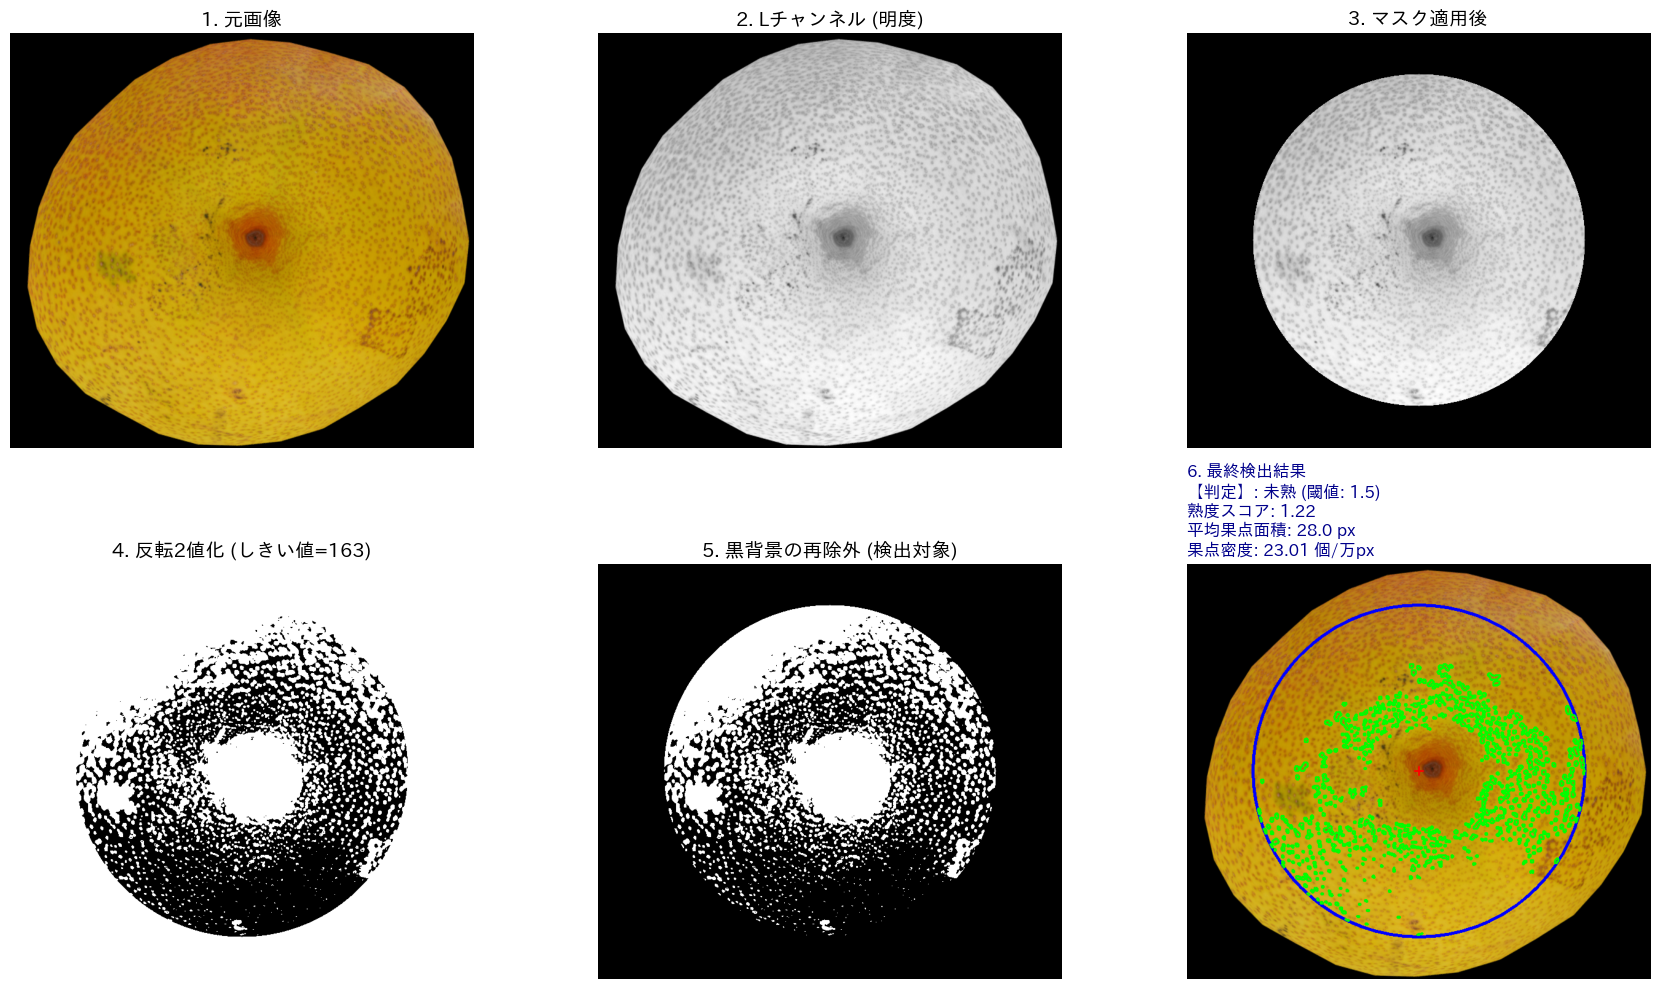

In [ ]:
# グラフの日本語化ライブラリを自動インストール
!pip install -q japanize-matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import requests
from google.colab import files
import math

# ==============================================================================
# 1. Colab フォーム設定
# ==============================================================================
#@title  ナシ果点検出・熟度分析 { run: "auto" }
入力モード = "サンプル画像を使用" #@param ["サンプル画像を使用", "自分の画像をアップロード"]
二値化のしきい値 = 163 #@param {type:"slider", min:0, max:255, step:1}
果点の最小面積 = 5 #@param {type:"slider", min:0, max:50, step:1}
果点の最大面積 = 150 #@param {type:"slider", min:50, max:1000, step:10}
円筒半径比率 = 0.40 #@param {type:"slider", min:0.1, max:0.9, step:0.05}

# 【新規追加パラメータ】
熟度判定閾値 = 1.5 #@param {type:"slider", min:0.5, max:5.0, step:0.1}
円筒中心X比率 = 0.50 #@param {type:"slider", min:0.0, max:1.0, step:0.01}
円筒中心Y比率 = 0.50 #@param {type:"slider", min:0.0, max:1.0, step:0.01}

サンプル画像URL = "https://github.com/1900690/pear_ripeness_analysis/raw/main/images/pear_sample.png"

# ==============================================================================
# 2. 状態管理 (キャッシュ)
# ==============================================================================
class ImageCache:
    def __init__(self):
        self.image_bgr = None
        self.mode = None

    def get_image(self, mode, url):
        if self.mode != mode or self.image_bgr is None:
            if mode == "サンプル画像を使用":
                print(" GitHubからサンプル画像をダウンロードしています...")
                self.image_bgr = self._download_image(url)
            else:
                print(" ナシの画像をアップロードしてください...")
                self.image_bgr = self._upload_image()
            self.mode = mode
        return self.image_bgr

    def _download_image(self, url):
        resp = requests.get(url)
        arr = np.asarray(bytearray(resp.content), dtype=np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_COLOR)

    def _upload_image(self):
        uploaded = files.upload()
        if len(uploaded) == 0:
            print("画像がアップロードされませんでした。")
            return np.zeros((400, 400, 3), dtype=np.uint8)
        return cv2.imread(list(uploaded.keys())[0])

if 'image_cache' not in globals():
    image_cache = ImageCache()

# ==============================================================================
#  3. 画像処理コアロジック
# ==============================================================================
def create_circular_mask(height, width, radius_ratio, cx_ratio, cy_ratio):
    # フォームから指定された比率を元に中心点を計算
    center_x = int(width * cx_ratio)
    center_y = int(height * cy_ratio)
    radius = int(min(height, width) * radius_ratio)

    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.circle(mask, (center_x, center_y), radius, 255, -1)
    return mask, (center_x, center_y, radius)

def process_image_pipeline(img_bgr, threshold_val, radius_ratio, cx_ratio, cy_ratio):
    height, width = img_bgr.shape[:2]
    mask, circle_info = create_circular_mask(height, width, radius_ratio, cx_ratio, cy_ratio)

    lab_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel, _, _ = cv2.split(lab_img)

    masked_l_channel = cv2.bitwise_and(l_channel, l_channel, mask=mask)
    _, binarized = cv2.threshold(masked_l_channel, threshold_val, 255, cv2.THRESH_BINARY_INV)
    binarized_masked = cv2.bitwise_and(binarized, binarized, mask=mask)

    return {
        "l_channel": l_channel,
        "masked_l_channel": masked_l_channel,
        "binarized": binarized,
        "binarized_masked": binarized_masked,
        "circle_info": circle_info
    }

def analyze_and_draw_contours(img_bgr, binarized_masked, circle_info, min_area, max_area):
    contours, _ = cv2.findContours(binarized_masked, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    center_x, center_y, radius = circle_info

    # マスクの円を描画
    cv2.circle(result_img, (center_x, center_y), radius, (0, 0, 255), 3)
    # 中心点に小さな十字マークを描画
    cv2.drawMarker(result_img, (center_x, center_y), (255, 0, 0), cv2.MARKER_CROSS, 15, 2)

    dot_count = 0
    total_dot_area = 0.0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            dot_count += 1
            total_dot_area += area
            cv2.drawContours(result_img, [cnt], -1, (0, 255, 0), 2)

    return result_img, dot_count, total_dot_area

# ==============================================================================
# 4. 熟度評価システム
# ==============================================================================
def calculate_ripeness(dot_count, total_dot_area, circle_info, score_thresh):
    _, _, radius = circle_info
    mask_area = math.pi * (radius ** 2)

    if dot_count == 0:
        return 0.0, 0.0, 0.0, "判定不可"

    # 1. 平均果点面積
    avg_area = total_dot_area / dot_count

    # 2. 果点密度（1万pxあたり）
    density = (dot_count / mask_area) * 10000

    # 3. 熟度スコア
    ripeness_score = avg_area / (density + 1e-6)

    # フォームから渡された「熟度判定閾値」を元に判定
    if ripeness_score > score_thresh:
        status = "適熟"
    else:
        status = "未熟"

    return avg_area, density, ripeness_score, status

# ==============================================================================
# 5. 描画・実行制御
# ==============================================================================
def plot_debug_results(img_bgr, pipeline_results, result_img, metrics, thresh, score_thresh):
    avg_area, density, score, status = metrics
    plt.figure(figsize=(18, 10))

    info_text = (
        f"6. 最終検出結果\n"
        f"【判定】: {status} (閾値: {score_thresh:.1f})\n"
        f"熟度スコア: {score:.2f}\n"
        f"平均果点面積: {avg_area:.1f} px\n"
        f"果点密度: {density:.2f} 個/万px"
    )

    images = [
        (cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), "1. 元画像"),
        (pipeline_results["l_channel"], "2. Lチャンネル (明度)"),
        (pipeline_results["masked_l_channel"], "3. マスク適用後"),
        (pipeline_results["binarized"], f"4. 反転2値化 (しきい値={thresh})"),
        (pipeline_results["binarized_masked"], "5. 黒背景の再除外 (検出対象)"),
        (result_img, info_text)
    ]

    for i, (img, title) in enumerate(images, 1):
        plt.subplot(2, 3, i)
        plt.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
        if i == 6:
            plt.title(title, fontsize=12, loc='left', color='darkblue', fontweight='bold')
        else:
            plt.title(title, fontsize=14)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def main():
    img_bgr = image_cache.get_image(入力モード, サンプル画像URL)

    # パイプライン処理に半径比率と中心点比率を渡す
    pipeline_results = process_image_pipeline(img_bgr, 二値化のしきい値, 円筒半径比率, 円筒中心X比率, 円筒中心Y比率)

    result_img, dot_count, total_dot_area = analyze_and_draw_contours(
        img_bgr, pipeline_results["binarized_masked"], pipeline_results["circle_info"], 果点の最小面積, 果点の最大面積
    )

    # 熟度判定にユーザー指定の閾値を渡す
    metrics = calculate_ripeness(dot_count, total_dot_area, pipeline_results["circle_info"], 熟度判定閾値)

    plot_debug_results(img_bgr, pipeline_results, result_img, metrics, 二値化のしきい値, 熟度判定閾値)

if __name__ == "__main__":
    main()

#アプリ化について

DEMOアプリを作成しました。[ここから](https://huggingface.co/spaces/sisetuengei/pear_ripeness_analysis)アクセスできます。